In [6]:

# DAY 1: IMAGE PREPROCESSING AND DATA EXPLORATION

# Step 1: Install + Upgrade libraries
!pip install torch torchvision matplotlib opencv-python numpy pandas pillow -q
!pip install kaggle --upgrade -q  # kaggle update

# Step 2: Download dataset from Kaggle - SILENT + FORCE OVERWRITE
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation -q
!unzip -qo lgg-mri-segmentation.zip -d lgg_mri_data  # -q quiet, -o overwrite
!rm lgg-mri-segmentation.zip

# Step 3: Import libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("Dataset downloaded and extracted successfully!")
print(f"Data folder: lgg_mri_data")
print("All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 12.5 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
Dataset downloaded and extracted successfully!
Data folder: lgg_mri_data
All libraries imported successfully!


Total patients: 110
Total images: 3929
Total masks: 3929

Showing sample: TCGA_CS_4941_19960909_1.tif


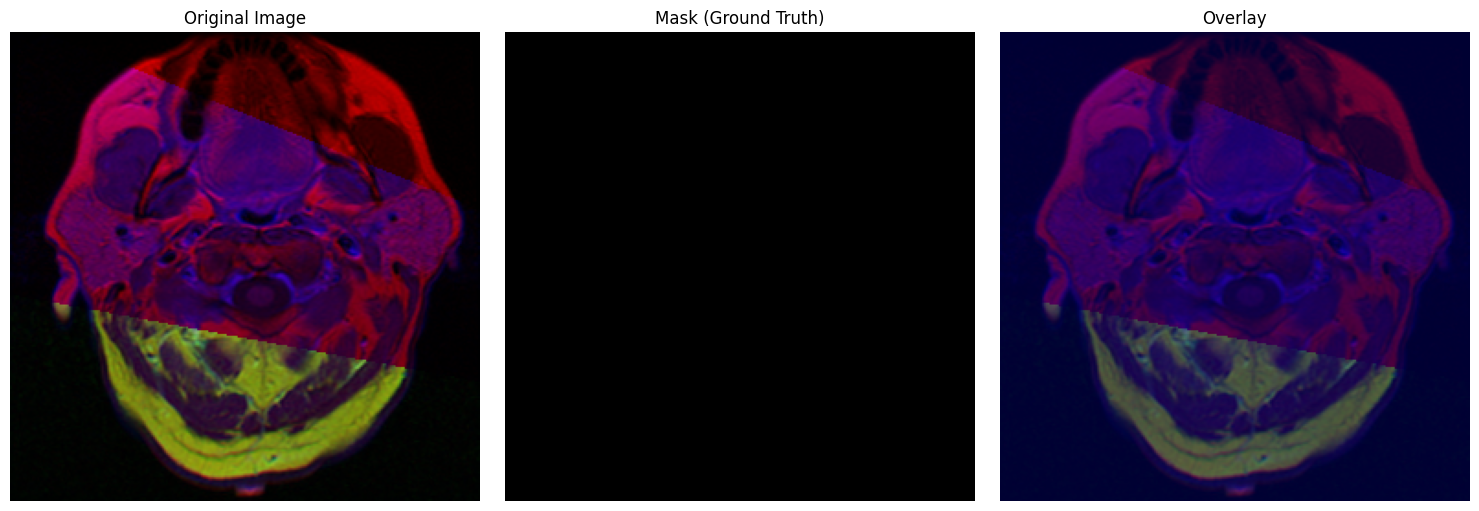

Image shape: (256, 256, 3)
Mask shape: (256, 256)
Image pixel range: 0 to 215
Mask pixel range: 0 to 0
Mask unique values: [0]
Percentage of foreground: 0.00%


In [8]:

# EXPLORE THE DATASET

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define path - dataset ka asal structure ye hai
DATA_DIR = Path('lgg_mri_data/kaggle_3m')

# Get all patient folders
patient_folders = sorted([f for f in DATA_DIR.iterdir() if f.is_dir()])
print(f"Total patients: {len(patient_folders)}")

# Get list of image files and their masks
image_files = []
mask_files = []

for patient_dir in patient_folders:
   
    imgs = sorted([f for f in patient_dir.glob('*.tif') if '_mask' not in f.name])
   
    masks = sorted([f for f in patient_dir.glob('*_mask.tif')])

    image_files.extend(imgs)
    mask_files.extend(masks)

print(f"Total images: {len(image_files)}")
print(f"Total masks: {len(mask_files)}")

# Check if 1-to-1 mapping 
assert len(image_files) == len(mask_files), "Image and mask count not matching!"

# Display a sample image and its mask
def display_sample(image_path, mask_path):
    """
    Display an image and its corresponding mask side by side
    """
    # Load image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load mask
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Display image
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Display mask
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mask (Ground Truth)')
    axes[1].axis('off')

    # Display overlay
    axes[2].imshow(image)
    axes[2].imshow(mask, cmap='jet', alpha=0.4)
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Print image statistics
    print(f"Image shape: {image.shape}")
    print(f"Mask shape: {mask.shape}")
    print(f"Image pixel range: {image.min()} to {image.max()}")
    print(f"Mask pixel range: {mask.min()} to {mask.max()}")
    print(f"Mask unique values: {np.unique(mask)}")
    print(f"Percentage of foreground: {(mask > 0).sum() / mask.size * 100:.2f}%")

# Display first sample
if len(image_files) > 0 and len(mask_files) > 0:
    print(f"\nShowing sample: {image_files[0].name}")
    display_sample(image_files[0], mask_files[0])
else:
    print("No images found. Check DATA_DIR path")


Found tumor in: TCGA_CS_4941_19960909_10.tif
Foreground pixels: 1426


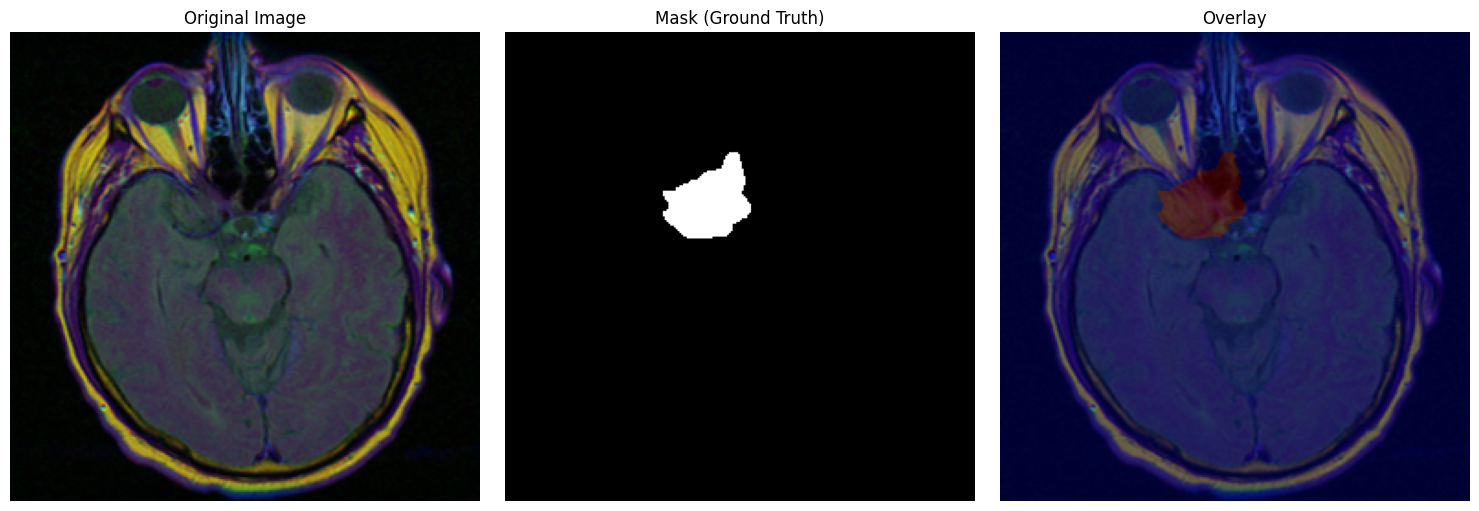

Image shape: (256, 256, 3)
Mask shape: (256, 256)
Mask pixel range: 0 to 255
Mask unique values: [  0 255]
Percentage of foreground: 2.18%


In [9]:
# Display a sample image that HAS tumor
def display_sample_with_tumor(image_files, mask_files, max_search=100):
    """
    Find first image with foreground in mask and display it
    """
    for i in range(min(max_search, len(image_files))):
        mask = cv2.imread(str(mask_files[i]), cv2.IMREAD_GRAYSCALE)

        if mask is None:
            continue

        foreground_pixels = (mask > 0).sum()

        if foreground_pixels > 0: # tumor mila
            print(f"\nFound tumor in: {image_files[i].name}")
            print(f"Foreground pixels: {foreground_pixels}")

            # Load image
            image = cv2.imread(str(image_files[i]))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Create figure
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            axes[0].imshow(image)
            axes[0].set_title('Original Image')
            axes[0].axis('off')

            axes[1].imshow(mask, cmap='gray')
            axes[1].set_title('Mask (Ground Truth)')
            axes[1].axis('off')

            axes[2].imshow(image)
            axes[2].imshow(mask, cmap='jet', alpha=0.4)
            axes[2].set_title('Overlay')
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

            # Print stats
            print(f"Image shape: {image.shape}")
            print(f"Mask shape: {mask.shape}")
            print(f"Mask pixel range: {mask.min()} to {mask.max()}")
            print(f"Mask unique values: {np.unique(mask)}")
            print(f"Percentage of foreground: {foreground_pixels / mask.size * 100:.2f}%")
            return

    print("No image with tumor found in first", max_search, "samples")

# Use this instead of display_sample(image_files[0], mask_files[0])
display_sample_with_tumor(image_files, mask_files)

Loaded 3929 image-mask pairs
Train samples: 3143
Val samples: 786
Found tumor sample at index: 2
Image tensor shape: torch.Size([1, 256, 256])
Mask tensor shape: torch.Size([1, 256, 256])
Foreground %: 2.18%


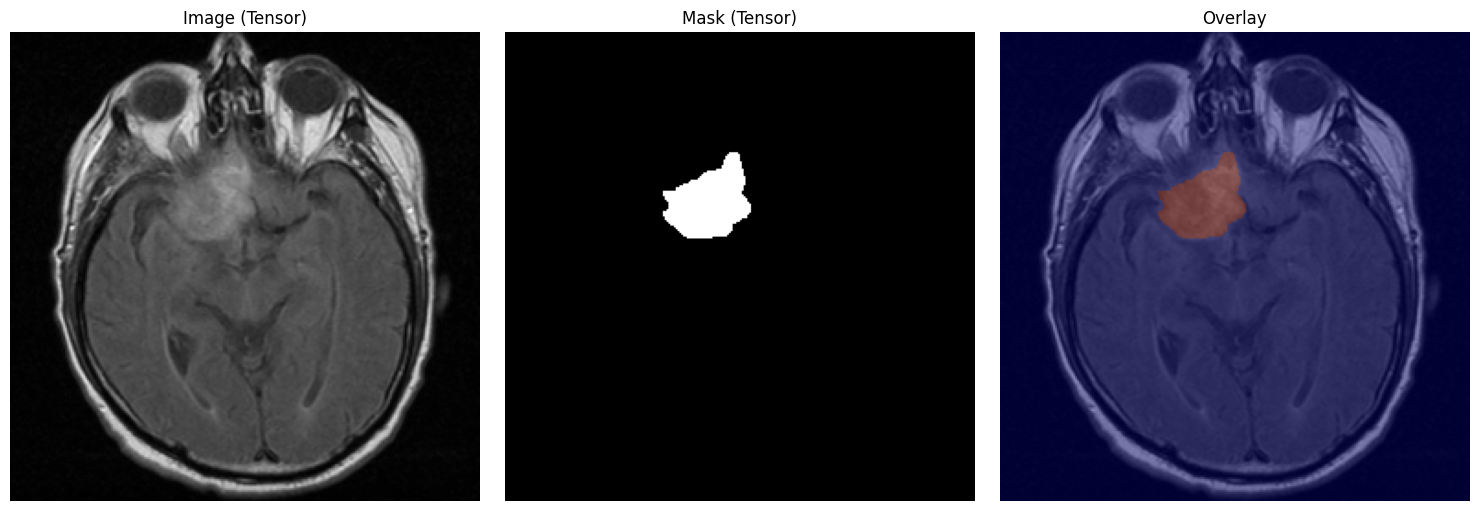

In [13]:

# CUSTOM DATASET CLASS


class MedicalSegmentationDataset(Dataset):
    def __init__(self, data_dir, target_size=(256, 256)):
        self.data_dir = Path(data_dir)
        self.target_size = target_size
        self.image_files = []
        self.mask_files = []
        for patient_dir in sorted(self.data_dir.iterdir()):
            if patient_dir.is_dir():
                imgs = sorted([f for f in patient_dir.glob('*.tif') if '_mask' not in f.name])
                for img_file in imgs:
                    mask_file = img_file.parent / f"{img_file.stem}_mask.tif"
                    if mask_file.exists():
                        self.image_files.append(img_file)
                        self.mask_files.append(mask_file)
        print(f"Loaded {len(self.image_files)} image-mask pairs")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load as GRAYSCALE
        image = cv2.imread(str(self.image_files[idx]), cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, self.target_size, interpolation=cv2.INTER_LINEAR)
        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0) # (1, H, W)

        mask = cv2.imread(str(self.mask_files[idx]), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=0) # (1, H, W)

        return torch.from_numpy(image), torch.from_numpy(mask)

# ============================================
# TEST THE DATASET CLASS + Train/Val Split
# ============================================

def test_dataset():
    """Test the dataset class and return train/val split"""
    
    DATA_DIR = Path('lgg_mri_data/kaggle_3m')
    dataset = MedicalSegmentationDataset(data_dir=DATA_DIR, target_size=(256, 256))
    
    # Train/Val split 80/20
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    
    # Find first sample that has tumor
    sample_idx = 0
    for i in range(len(dataset)):
        _, mask = dataset[i]
        if mask.sum() > 0: 
            sample_idx = i
            print(f"Found tumor sample at index: {i}")
            break
    
    image, mask = dataset[sample_idx]
    print(f"Image tensor shape: {image.shape}")
    print(f"Mask tensor shape: {mask.shape}")
    print(f"Foreground %: {mask.sum() / mask.numel() * 100:.2f}%")
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    img_np = image.squeeze().numpy()
    mask_np = mask.squeeze().numpy()
    
    axes[0].imshow(img_np, cmap='gray')
    axes[0].set_title('Image (Tensor)')
    axes[0].axis('off')
    
    axes[1].imshow(mask_np, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Mask (Tensor)')
    axes[1].axis('off')
    
    axes[2].imshow(img_np, cmap='gray')
    axes[2].imshow(mask_np, cmap='jet', alpha=0.4)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return train_dataset, val_dataset # 2 cheezein return

# Ab ye chal jayega
train_dataset, val_dataset = test_dataset()